# Imports and helpers

In [1]:
import os, glob, sys, time, datetime, re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import seaborn as sns

In [2]:
def set_labels_and_title(
    ax,xlabel='',ylabel='',title='',title_pad=16,
    ylabel_coords=(0,1.01),
    ylabel_style='horizontal'
):
    '''
    Convenience function for setting x and y axis labels and title in matplotlib
    Provides an option to make the ylabel horizontal and placed at the top of the chart,
    with the title padded upwards to make room.
    ylabel_style = 'horizontal' or 'vertical', if 'vertical', ylabel_coords and title_pad are ignored
    '''
    ax.set_xlabel(xlabel)
    if ylabel_style == 'horizontal':
        ax.set_ylabel(ylabel,rotation='horizontal',ha='left')
        ax.yaxis.set_label_coords(*ylabel_coords)
        ax.set_title(title,pad=title_pad,va='bottom')
    else: 
        ax.set_ylabel(ylabel)
        ax.set_title(title)
def rgb_to_hex(rgb):
    """
    Converts an RGB tuple (0-255 values) to a hexadecimal color string.
    """
    # Convert 0-1 RGB values to 0-255
    if any((x<1) and (x>0) for x in rgb):
        rgb = [int(x*255) for x in rgb]
    return "#{:02x}{:02x}{:02x}".format(*rgb)

In [3]:
import matplotlib as mpl
import matplotlib.font_manager as fm
from cycler import cycler
# Default color cycle taken from sns.color_palette('colorblind'), but with a few colors removed
default_color_cycle = ['#0173b2','#de8f05','#029e73','#d55e00','#cc78bc','#949494','#56b4e9','#ece133']
# Set custom plot settings
custom_rcParams = {
    'font.family':'sans-serif','font.sans-serif':['DejaVu Sans', 'Arial'],
    'axes.edgecolor':rgb_to_hex(3*[0.5]), 'xtick.color':rgb_to_hex(3*[0.5]), 'ytick.color':rgb_to_hex(3*[0.5]), 'figure.facecolor':'white',
    'xtick.labelcolor': rgb_to_hex(3*[0.1]),'ytick.labelcolor': rgb_to_hex(3*[0.1]),#'inherit',
    'axes.labelcolor': rgb_to_hex(3*[0.1]),'axes.titlecolor': 'auto',
    'axes.prop_cycle': cycler('color',default_color_cycle),
    'grid.alpha': 1.0,'grid.color': rgb_to_hex(3*[0.9]),'grid.linestyle': '-','grid.linewidth': 0.5,
    'axes.grid': True,'axes.grid.axis': 'both','axes.grid.which': 'major',
    'axes.labelpad': 4.0, 'axes.labelsize': 'medium', 'axes.labelweight': 'normal','axes.linewidth': 0.8,
    'axes.spines.top': False,'axes.spines.right': False,'axes.spines.left': False,
    'axes.titlelocation': 'left',
    'axes.axisbelow': True,#'line',
}
mpl.rcParams.update(custom_rcParams)

# Import data

In [4]:
data_dir = 'data'
fname = 'air_permits_VA.csv'
date_parser = lambda c: pd.to_datetime(c, format='%m/%d/%Y', errors='coerce')
df_gensets_VA = pd.read_csv(os.path.join(data_dir,fname),header=1,parse_dates=['original_permit_date','latest_permit_date'],date_format='%m/%d/%Y')
df_gensets_VA.original_permit_date = pd.to_datetime(df_gensets_VA.original_permit_date, errors='coerce')
df_gensets_VA_expanded = df_gensets_VA.loc[df_gensets_VA.index.repeat(df_gensets_VA['quantity'])].reset_index(drop=True)

In [5]:
df_gensets_VA_expanded.shape

(10684, 44)

In [6]:
df = df_gensets_VA_expanded.copy()
# Exclude transitory engines (just used during construction) and exclude gas fired turbines
df = df[(df.transitory == False) & (df.equipment_type.isin(['emergency diesel genset', 'non-emergency diesel genset','natural gas generator']))]
df.loc[:,'original_permit_year'] = pd.DatetimeIndex(df['original_permit_date']).year
df.loc[:,'capacity_MWe'] = df['capacity_kWe']/1e3
df.loc[:,'capacity_GWe'] = df['capacity_kWe']/1e6
# If no original permit date is available, assume the latest permit date is original
df.loc[:,'original_permit_date'] = df['original_permit_date'].fillna(df['latest_permit_date'])

In [7]:
# Emissions calculations
avg_efficiency = 0.915
g_per_lb = 453.592
# Calculate NOx emissions with a brake power kW basis, assuming an average efficiency
df.loc[:,'NOx_g_per_kWh_brake'] = df.NOx_lb_per_hr / (df.capacity_kWe/avg_efficiency) * g_per_lb
#CO_lb_per_hr, VOC_lb_per_hr, PM_lb_per_hr
df.loc[:,'PM_g_per_kWh_brake'] = df.PM_lb_per_hr / (df.capacity_kWe/avg_efficiency) * g_per_lb
df.loc[:,'VOC_g_per_kWh_brake'] = df.VOC_lb_per_hr / (df.capacity_kWe/avg_efficiency) * g_per_lb
df.loc[:,'CO_g_per_kWh_brake'] = df.CO_lb_per_hr / (df.capacity_kWe/avg_efficiency) * g_per_lb
df.loc[:,'PM_g_per_kWhe'] = df.PM_lb_per_hr / (df.capacity_kWe) * g_per_lb
df.loc[:,'VOC_g_per_kWhe'] = df.VOC_lb_per_hr / (df.capacity_kWe) * g_per_lb
df.loc[:,'CO_g_per_kWhe'] = df.CO_lb_per_hr / (df.capacity_kWe) * g_per_lb

In [8]:
# Simplify listed tiers to just "Tier 2" (combining Tier 1 and 2), "Tier 2 + SCR", and "Tier 4"
df.loc[:,'tier_simple'] = df.tier.copy()
df.loc[df.SCR==False,'tier_simple'] = "Tier 2"
df.loc[(df.SCR==True) & (df.tier!='Tier 4'),'tier_simple'] = "Tier 2 + SCR"

In [9]:
print(f"{len(df[(df.fuel_type=='diesel')])} - Diesel units permitted in VA")
print(f"{df[(df.fuel_type=='diesel')].capacity_GWe.sum():.1f} GW - Permitted capacity for diesel units in VA")
print(f"{df[(df.fuel_type=='diesel')].capacity_GWe.sum() / (df.capacity_GWe.sum())*100:.1f}% - Fraction of permitted capacity that are diesel units in VA")

print(f"{df[(df.fuel_type=='diesel') & (df.original_permit_date<'2024-06-01')].capacity_GWe.sum() / (df[(df.original_permit_date<'2024-06-01')].capacity_GWe.sum())*100:.1f}% - "
      f"Fraction of installed capacity that are diesel units in VA, assuming 1.5 year construction timeline.")

10551 - Diesel units permitted in VA
27.0 GW - Permitted capacity for diesel units in VA
99.7% - Fraction of permitted capacity that are diesel units in VA
99.6% - Fraction of installed capacity that are diesel units in VA, assuming 1.5 year construction timeline.


# Permit date analysis

## Median permit date, by unit

In [10]:
print(f"Date when half of the genset units were permitted: {df_gensets_VA_expanded.original_permit_date.median()}")

Date when half of the genset units were permitted: 2022-09-09 00:00:00


## Median permit date, by capacity

In [11]:
df_sorted = df.sort_values(by='original_permit_date', ascending=True)
df_sorted.loc[:,'cumulative_capacity_GWe'] = df_sorted.capacity_GWe.cumsum()
# Find row where half of the current total genset capacity was permitted
median_capacity_idx = np.argmin(np.abs(df_sorted.cumulative_capacity_GWe.values - df_sorted.capacity_GWe.sum()/2))

print(f"Date when half of genset capacity was permitted: {df_sorted.original_permit_date.iloc[median_capacity_idx].strftime('%m/%d/%Y')}")

Date when half of genset capacity was permitted: 03/23/2023


# Permitted capacity over time

In [12]:
print('Fraction of capacity deployed in each tier')
df.groupby('tier_simple')['capacity_GWe'].sum() / df['capacity_GWe'].sum()

Fraction of capacity deployed in each tier


tier_simple
Tier 2          0.733031
Tier 2 + SCR    0.080036
Tier 4          0.186932
Name: capacity_GWe, dtype: float64

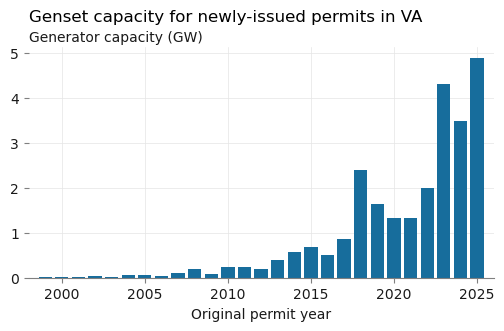

In [13]:
fig,ax=plt.subplots(figsize=(6,3))
sns.barplot(data=df,x='original_permit_year',y='capacity_GWe',estimator='sum',native_scale=True,ax=ax,errorbar=None)
set_labels_and_title(
    ax,
    xlabel='Original permit year',
    ylabel='Generator capacity (GW)',
    title='Genset capacity for newly-issued permits in VA',
)
ax.set_xlim(1998,2026)
plt.show()

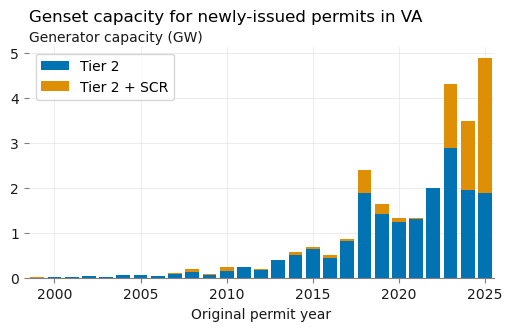

In [15]:
capacity_by_year = df.groupby(['original_permit_year', 'SCR'])['capacity_GWe'].sum().unstack(fill_value=0)
# Create stacked bar plot
ax = capacity_by_year.plot(kind='bar', stacked=True, figsize=(6,3),width=0.8)
set_labels_and_title(
    ax,
    xlabel='Original permit year',
    ylabel='Generator capacity (GW)',
    title='Genset capacity for newly-issued permits in VA',
)
ax.legend(labels=['Tier 2', 'Tier 2 + SCR'])

# Set x-axis range and ticks for every 5 years from 2000 to 2025
years_to_show = range(2000, 2030, 5)  # 2000, 2005, 2010, 2015, 2020, 2025
year_indices = [list(capacity_by_year.index).index(year) for year in years_to_show if year in capacity_by_year.index]
ax.set_xticks(year_indices)
ax.set_xticklabels(years_to_show, rotation=0)
ax.set_xlim(2.5, len(capacity_by_year) - 0.5)  # Keep all bars visible
plt.show()

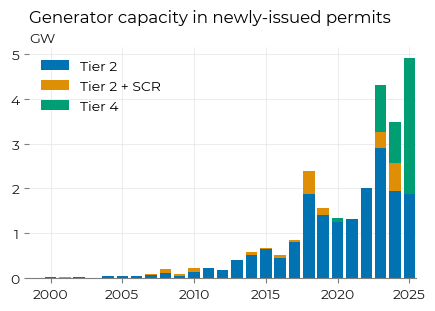

In [12]:
capacity_by_year = df[(df.fuel_type=='diesel')].groupby(['original_permit_year', 'tier_simple'])['capacity_GWe'].sum().unstack(fill_value=0)
# Create stacked bar plot
ax = capacity_by_year.plot(kind='bar', stacked=True, figsize=(5,3),width=0.8)
set_labels_and_title(
    ax,
    xlabel='',#'Original permit year',
    ylabel='GW',#'Permitted generator capacity (GW)',
    title='Generator capacity in newly-issued permits',
)
# ax.set_xlabel('Original Permit Year')
# ax.set_ylabel('Total generator capacity (GW)')
# ax.set_title('Genset capacity for newly-issued permits in VA')
ax.legend(framealpha=0)#,bbox_to_anchor=(0.035,1),loc='upper left')#labels=['Tier 2', 'Tier 2 + SCR'])

# Set x-axis range and ticks for every 5 years from 2000 to 2025
years_to_show = range(2000, 2030, 5)  # 2000, 2005, 2010, 2015, 2020, 2025
year_indices = [list(capacity_by_year.index).index(year) for year in years_to_show if year in capacity_by_year.index]
ax.set_xticks(year_indices)
ax.set_xticklabels(years_to_show, rotation=0)
ax.set_xlim(2.5, len(capacity_by_year) - 0.5)  # Keep all bars visible
save_plots("genset-capacity-issued-per-year_VA_tier-breakdown",plot_dir=plot_dir,bbox_inches='tight',transparent=True)

# Set partial transparency for the figure background (this isn't seeming to work
# fig.patch.set_alpha(0.75)
# ax.patch.set_alpha(0.75)
# save_plots("genset-capacity-issued-per-year_VA_tier-breakdown",plot_dir=plot_dir,bbox_inches='tight',transparent=False)
plt.show()

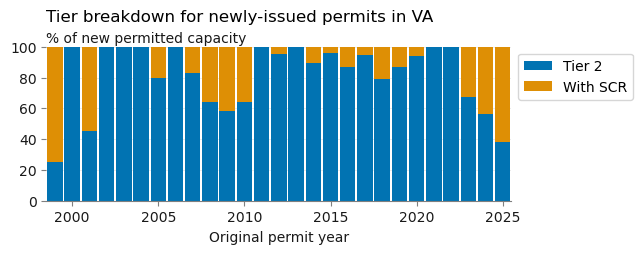

In [17]:
# fill_value adds 0's for any year/SCR combo that is empty/has no permits
capacity_by_year = df.groupby(['original_permit_year', 'SCR'])['capacity_GWe'].sum().unstack(fill_value=0)
# Make stacked bar plot using pandas built in plotting tools
ax = (capacity_by_year.div(capacity_by_year.sum(axis=1), axis=0) * 100).plot(kind='bar', stacked=True, figsize=(6,2),width=0.9)
# Customize the plot
set_labels_and_title(
    ax,
    xlabel='Original permit year',
    ylabel='% of new permitted capacity',
    title='Tier breakdown for newly-issued permits in VA',
)

ax.legend(labels=['Tier 2', 'With SCR'],bbox_to_anchor=(1,1),loc="upper left")

# Set x-axis range and ticks for every 5 years from 2000 to 2025
years_to_show = range(2000, 2030, 5) 
year_indices = [list(capacity_by_year.index).index(year) for year in years_to_show if year in capacity_by_year.index]
ax.set_xticks(year_indices)
ax.set_xticklabels(years_to_show, rotation=0)
ax.set_xlim(2.5, len(capacity_by_year) - 0.5)  # Keep all bars visible
ax.set_ylim(0,100)
plt.show()

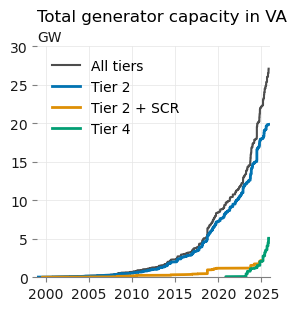

In [18]:
fig,ax=plt.subplots(figsize=(3,3))

df_sorted = df.sort_values(by='original_permit_date', ascending=True)
df_sorted.loc[:,'cumulative_capacity_GWe'] = df_sorted.capacity_GWe.cumsum()
df_sorted.loc[df_sorted.tier_simple=='Tier 2','cum_cap_tier2_GWe'] = df_sorted[df_sorted.tier_simple=='Tier 2'].capacity_GWe.cumsum()
df_sorted.loc[df_sorted.tier_simple=='Tier 2 + SCR','cum_cap_tier2_SCR_GWe'] = df_sorted[df_sorted.tier_simple=='Tier 2 + SCR'].capacity_GWe.cumsum()
df_sorted.loc[df_sorted.tier_simple=='Tier 4','cum_cap_tier4_GWe'] = df_sorted[df_sorted.tier_simple=='Tier 4'].capacity_GWe.cumsum()

plt.plot(df_sorted.original_permit_date,df_sorted.cumulative_capacity_GWe,color=3*[0.3],label='All tiers')
cols = ['cum_cap_tier2_GWe','cum_cap_tier2_SCR_GWe','cum_cap_tier4_GWe']
for ti,tier in enumerate(['Tier 2','Tier 2 + SCR','Tier 4']):
    ax.plot(
        df_sorted[df_sorted.tier_simple==tier].original_permit_date,
        df_sorted[df_sorted.tier_simple==tier][cols[ti]],
        label=tier,lw=2
    )
ax.legend(framealpha=0,bbox_to_anchor=(0.01,1),loc="upper left")
set_labels_and_title(
    ax,
    ylabel='GW',#'Generator capacity (GW)',
    title='Total generator capacity in VA'#'Total permitted generator capacity\nfor data centers in VA',
)
ax.set_xlim(np.datetime64('1999-01-01'),np.datetime64('2026-01-01'))
ax.set_xticks([np.datetime64(f'{x}-01-01') for x in [2000,2005,2010,2015,2020,2025]])
ax.set_xticklabels([f'{x}' for x in [2000,2005,2010,2015,2020,2025]])
ax.set_ylim(0,30)
plt.show()

## Estimating installed capacity by end of 2024
Based on a 1-2 year construction timeline from the permit date, the below values allow us to estimate that 13-17 GW of gensets were installed by the end of 2024. Based on the estimate that VA comprises \~25% of all US data center capacity, this suggests that 50-70 GW genset capacity was installed nationwide by the end of 2024. This roughly comports (\~50 GW by 2024) with the estimate derived from the energy usage figures from Shehabi et al. 2024. 

In [19]:
def get_rows_closest_to_dates(df,target_dates=['2023-01-01'],date_col='original_permit_date'):
    '''
    Gets the rows in a pandas dataframe that are closest to each date in a list of target_dates
    '''
    dates_to_match = pd.DataFrame(
        pd.to_datetime(target_dates), 
        columns=['target_date']
    ).sort_values(by='target_date')
    df_sorted = df.sort_values(by=date_col)
    df_sorted = df_sorted.set_index(date_col)
    df_sorted[date_col] = df_sorted.index
    closest_rows = pd.merge_asof(
        dates_to_match,
        df_sorted,
        left_on='target_date',
        right_index=True, # Match against the index of df_sorted
        direction='nearest'
    )
    return closest_rows
closest_rows = get_rows_closest_to_dates(df_sorted,target_dates=['2017-12-31','2023-01-01', '2023-03-05', '2023-06-01', '2023-12-28','2024-12-10','2025-01-02'],date_col='original_permit_date')
closest_rows[['original_permit_date','cumulative_capacity_GWe','cum_cap_tier2_GWe']]

,original_permit_date,cumulative_capacity_GWe,cum_cap_tier2_GWe
0,2017-12-20,4.356860,3.902710
1,2023-01-06,13.157083,11.894543
2,2023-03-15,13.387558,12.105943
3,2023-06-08,14.333008,12.377393
4,2023-12-27,17.185058,14.512443
5,2024-12-03,21.999383,17.896618
6,2024-12-18,22.073133,NaN


## Generator unit capacity over time

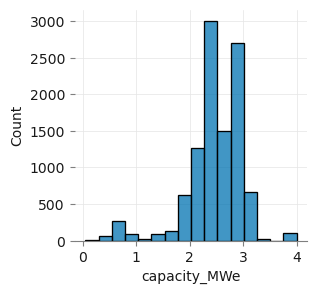

In [20]:
fig,ax=plt.subplots(figsize=(3,3))
sns.histplot(data=df[(df.fuel_type=='diesel')],x='capacity_MWe',ax=ax,binwidth=0.25)
plt.show()

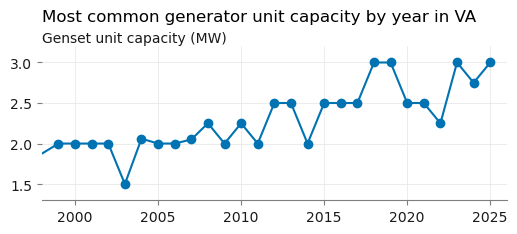

In [21]:
fig,ax=plt.subplots(figsize=(6,2))
modal_capacity = df.groupby('original_permit_year')['capacity_MWe'].agg(pd.Series.mode)
plt.plot(modal_capacity.index,modal_capacity.values,'-o')
set_labels_and_title(
    ax,
    ylabel='Genset unit capacity (MW)',
    title='Most common generator unit capacity by year in VA',
)
ax.set_xlim(1998,2026)
ax.set_ylim(1.3,3.2)
plt.show()

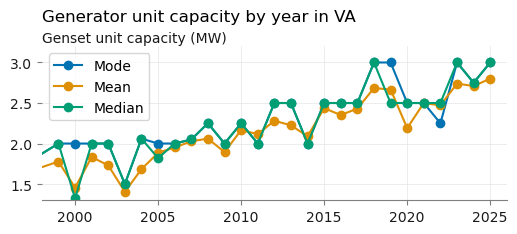

In [22]:
fig,ax=plt.subplots(figsize=(6,2))
modal_capacity = df.groupby('original_permit_year')['capacity_MWe'].agg(pd.Series.mode)
plt.plot(modal_capacity.index,modal_capacity.values,'-o',label='Mode')
mean_capacity = df.groupby('original_permit_year')['capacity_MWe'].mean()
plt.plot(mean_capacity.index,mean_capacity.values,'-o',label='Mean')
med_capacity = df.groupby('original_permit_year')['capacity_MWe'].median()
plt.plot(med_capacity.index,med_capacity.values,'-o',label='Median')
ax.legend()
set_labels_and_title(
    ax,
    ylabel='Genset unit capacity (MW)',
    title='Generator unit capacity by year in VA',
)
ax.set_xlim(1998,2026)
ax.set_ylim(1.3,3.2)
plt.show()

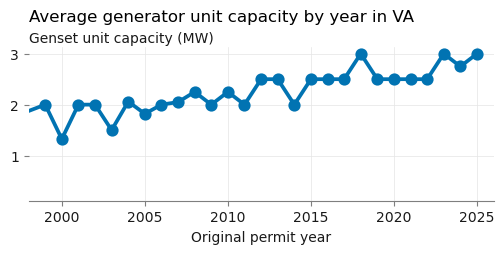

In [23]:
fig,ax=plt.subplots(figsize=(6,2))
sns.pointplot(data=df,x='original_permit_year',y='capacity_MWe',estimator='median',native_scale=True,ax=ax,errorbar=None)

set_labels_and_title(
    ax,
    xlabel='Original permit year',
    ylabel='Genset unit capacity (MW)',
    title='Average generator unit capacity by year in VA',
)

ax.set_xlim(1998,2026)
#x.set_ylim(0.8,3.2)
plt.show()

# Emissions

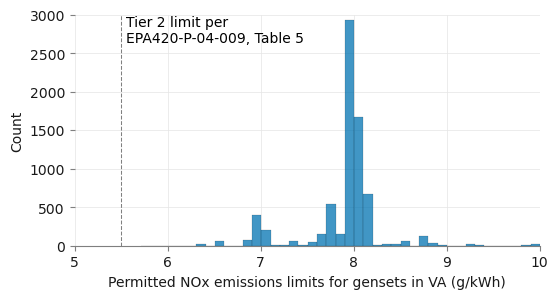

In [25]:
fig,ax=plt.subplots(figsize=(6,3))
sub_df = df[(df.fuel_type=='diesel') & (df.SCR==False) & (df.capacity_kWe>=2000)]
sns.histplot(data=sub_df,x='NOx_g_per_kWh_brake',ax=ax,binwidth=0.1)
ax.axis([5,10,0,3000])
plt.plot(2*[5.5],[0,4750],'--',color='gray',lw=0.75)
ax.text(5.55,3000,'Tier 2 limit per\nEPA420-P-04-009, Table 5',va='top') #40 CFR 1039, appendix I
ax.set_xlabel('Permitted NOx emissions limits for gensets in VA (g/kWh)')
plt.show()

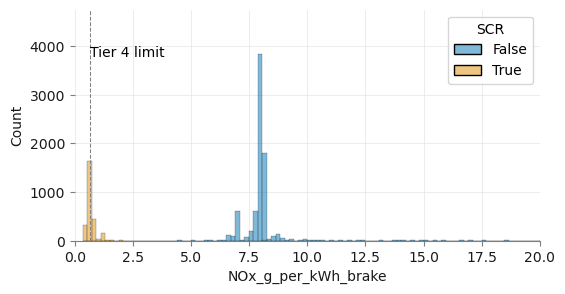

In [26]:
fig,ax=plt.subplots(figsize=(6,3))
sns.histplot(data=df[df.fuel_type=='diesel'],x='NOx_g_per_kWh_brake',hue='SCR',ax=ax)
ax.axis([0,20,0,4750])
plt.plot([0.67,0.67],[0,4750],'--',color='gray',lw=0.75)
ax.text(0.67,4000,'Tier 4 limit',va='top')
plt.show()

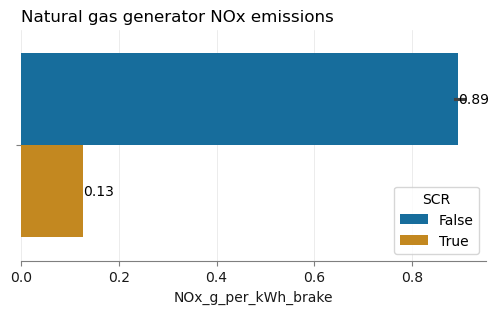

In [27]:
fig,ax=plt.subplots(figsize=(6,3))
ax.set_title('Natural gas generator NOx emissions')
sns.barplot(data=df[df.fuel_type=='natural gas'],x='NOx_g_per_kWh_brake',hue='SCR',ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
#ax.axis([0,20,0,4750])
#plt.plot([0.67,0.67],[0,4750],'--',color='gray',lw=0.75)
plt.show()

In [28]:
df.loc[:,'PM_controls'] = df.PM_controls.fillna('None')
df.loc[df.PM_controls.isin(['cDPF','DPF']),'PM_controls_simple'] = 'DPF'
df.loc[df.PM_controls.isin(['None','engine design']),'PM_controls_simple'] = 'None'

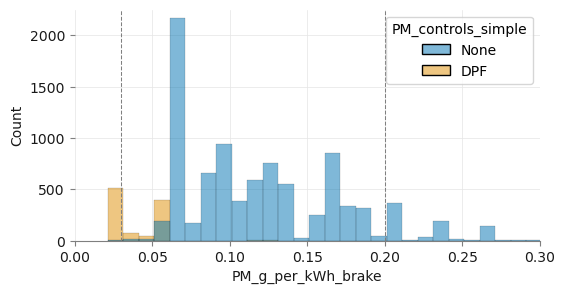

In [29]:
fig,ax=plt.subplots(figsize=(6,3))
sns.histplot(data=df[df.fuel_type=='diesel'],x='PM_g_per_kWh_brake',hue='PM_controls_simple',ax=ax,binwidth=0.01)
ax.axis([0,0.3,0,2250])
plt.plot([0.03,0.03],[0,2250],'--',color='gray',lw=0.75)
plt.plot([0.2,0.2],[0,2250],'--',color='gray',lw=0.75)
#ax.set_xlim(0,0.5)
plt.show()

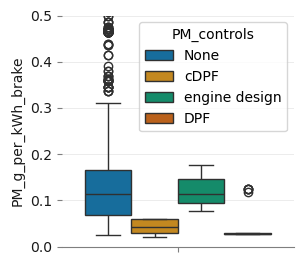

In [30]:
fig,ax=plt.subplots(figsize=(3,3))
sns.boxplot(data=df[df.fuel_type=='diesel'],y='PM_g_per_kWh_brake',hue='PM_controls',ax=ax)
#ax.axis([0,20,0,4750])
#plt.plot([0.03,0.03],[0,4750],'--',color='gray',lw=0.75)
ax.set_ylim(0,0.5)
plt.show()

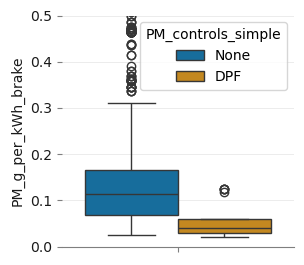

In [31]:
fig,ax=plt.subplots(figsize=(3,3))
sns.boxplot(data=df[df.fuel_type=='diesel'],y='PM_g_per_kWh_brake',hue='PM_controls_simple',ax=ax)
#ax.axis([0,20,0,4750])
#plt.plot([0.03,0.03],[0,4750],'--',color='gray',lw=0.75)
ax.set_ylim(0,0.5)
plt.show()

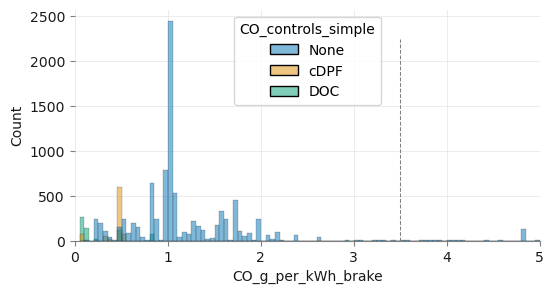

In [32]:
df.loc[:,'CO_controls'] = df.CO_controls.fillna('None')
df['CO_controls_simple'] = df.CO_controls
df.loc[df.PM_controls.isin(['cDPF']),'CO_controls_simple'] = 'cDPF'

fig,ax=plt.subplots(figsize=(6,3))
sns.histplot(data=df[df.fuel_type=='diesel'],x='CO_g_per_kWh_brake',hue='CO_controls_simple',ax=ax,binwidth=0.05)
plt.plot([3.5,3.5],[0,2250],'--',color='gray',lw=0.75)
ax.set_xlim(0,5)
plt.show()

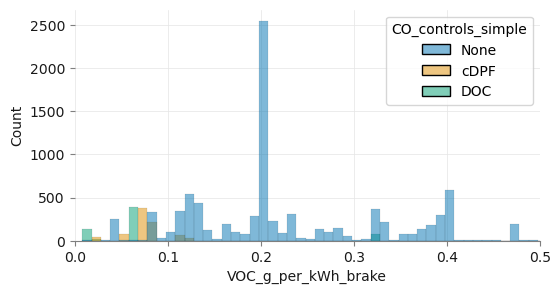

In [33]:
df.loc[:,'CO_controls'] = df.CO_controls.fillna('None')
df['CO_controls_simple'] = df.CO_controls
df.loc[df.PM_controls.isin(['cDPF']),'CO_controls_simple'] = 'cDPF'

fig,ax=plt.subplots(figsize=(6,3))
sns.histplot(data=df[df.fuel_type=='diesel'],x='VOC_g_per_kWh_brake',hue='CO_controls_simple',ax=ax,binwidth=0.01)
ax.set_xlim(0,0.5)
plt.show()

In [34]:
def adjust_lightness(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

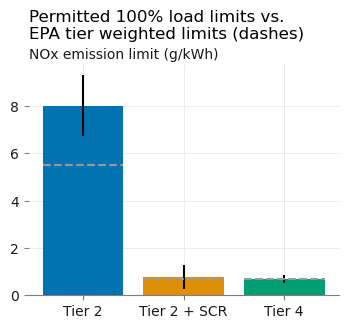

In [35]:
fig,ax=plt.subplots(figsize=(4,3))
x=0
x_vals = []
tiers = []
NSPS_levels = [5.5,0.67,0.67]
for ti,tier in enumerate(df.tier_simple.unique()):
    y=df[df.tier_simple==tier]['NOx_g_per_kWh_brake'].dropna()
    width = 0.8
    ax.bar(x,y.mean(),color=default_color_cycle[ti],yerr=y.std(),width=width)
    plt.plot([x-width/2,x+width/2],2*[NSPS_levels[ti]],'--',lw=1.5,color=3*[0.6])
    x_vals.append(x)
    tiers.append(tier)
    x+=1
ax.set_xticks(x_vals)
ax.set_xticklabels(tiers)
set_labels_and_title(
    ax,
    ylabel='NOx emission limit (g/kWh)',
    title='Permitted 100% load limits vs.\nEPA tier weighted limits (dashes)',
)

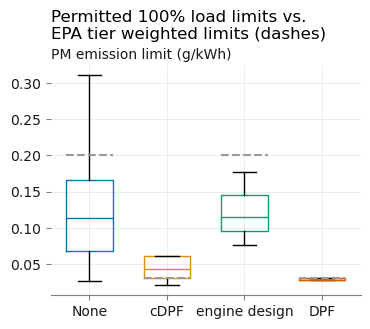

In [36]:
fig,ax=plt.subplots(figsize=(4,3))
x=0
x_vals = []
ctrls = []
NSPS_levels = [0.2,0.03,0.2,0.03]
col='PM_g_per_kWh_brake'
for ti,ctrl in enumerate(df.PM_controls.unique()):
    width = 0.6
    y=df[df.PM_controls==ctrl][col].dropna()
    ax.boxplot(y.values,positions=[x],
               widths=width,#patch_artist=True,
               showfliers=False,
               medianprops={'color':default_color_cycle[ti]},
               boxprops={'color':default_color_cycle[ti]})
    plt.plot([x-width/2,x+width/2],2*[NSPS_levels[ti]],'--',lw=1.5,color=3*[0.6])
    x_vals.append(x)
    ctrls.append(ctrl)
    x+=1
ax.set_xticks(x_vals)
ax.set_xticklabels(ctrls)
set_labels_and_title(
    ax,
    ylabel='PM emission limit (g/kWh)',
    title='Permitted 100% load limits vs.\nEPA tier weighted limits (dashes)',
)

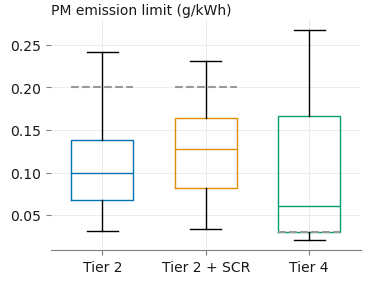

In [37]:
fig,ax=plt.subplots(figsize=(4,3))
x=0
x_vals = []
tiers = []
NSPS_levels = [0.2,0.2,0.03]
col='PM_g_per_kWh_brake'
for ti,tier in enumerate(df.tier_simple.unique()):
    width = 0.6
    y=df[df.tier_simple==tier][col].dropna()
    ax.boxplot(y.values,positions=[x],
               widths=width,#patch_artist=True,
               showfliers=False,
               medianprops={'color':default_color_cycle[ti]},
               boxprops={'color':default_color_cycle[ti]})
    plt.plot([x-width/2,x+width/2],2*[NSPS_levels[ti]],'--',lw=1.5,color=3*[0.6])
    x_vals.append(x)
    tiers.append(tier)
    x+=1
ax.set_xticks(x_vals)
ax.set_xticklabels(tiers)
set_labels_and_title(
    ax,
    ylabel='PM emission limit (g/kWh)',
    #title='Generator unit capacity by year in VA',
)

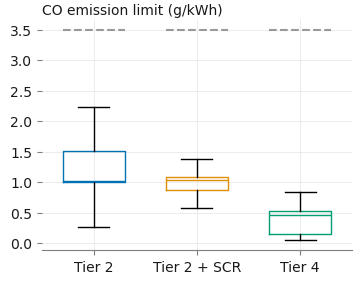

In [38]:
fig,ax=plt.subplots(figsize=(4,3))
x=0
x_vals = []
tiers = []
NSPS_levels = [3.5,3.5,3.5]
col='CO_g_per_kWh_brake'
for ti,tier in enumerate(df.tier_simple.unique()):
    width = 0.6
    y=df[df.tier_simple==tier][col].dropna()
    ax.boxplot(y.values,positions=[x],
               widths=width,#patch_artist=True,
               showfliers=False,
               medianprops={'color':default_color_cycle[ti]},
               boxprops={'color':default_color_cycle[ti]})
    plt.plot([x-width/2,x+width/2],2*[NSPS_levels[ti]],'--',lw=1.5,color=3*[0.6])
    x_vals.append(x)
    tiers.append(tier)
    x+=1

ax.set_xticks(x_vals)
ax.set_xticklabels(tiers)
#ax.set_yscale('log')
set_labels_and_title(
    ax,
    ylabel='CO emission limit (g/kWh)',
)

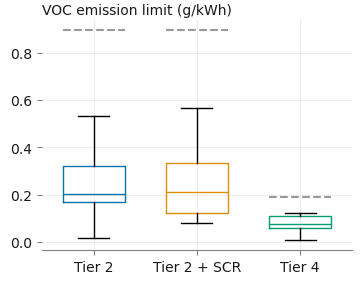

In [39]:
fig,ax=plt.subplots(figsize=(4,3))
x=0
x_vals = []
tiers = []
NSPS_levels = [0.9,0.9,0.19]
col='VOC_g_per_kWh_brake'
for ti,tier in enumerate(df.tier_simple.unique()):
    width = 0.6
    y=df[df.tier_simple==tier][col].dropna()
    ax.boxplot(y.values,positions=[x],
               widths=width,#patch_artist=True,
               showfliers=False,
               medianprops={'color':default_color_cycle[ti]},
               boxprops={'color':default_color_cycle[ti]})
    plt.plot([x-width/2,x+width/2],2*[NSPS_levels[ti]],'--',lw=1.5,color=3*[0.6])
    x_vals.append(x)
    tiers.append(tier)
    x+=1

ax.set_xticks(x_vals)
ax.set_xticklabels(tiers)
#ax.set_yscale('log')
set_labels_and_title(
    ax,
    ylabel='VOC emission limit (g/kWh)',
    #title='Generator unit capacity by year in VA',
)

# Manufacturer and model

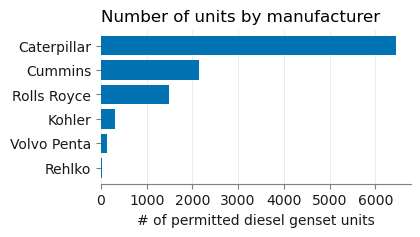

In [40]:
fig,ax=plt.subplots(figsize=(4,2))
# Exclude NG for this plot, and just show the top 6 manufacturers
df[df.fuel_type=='diesel']['manufacturer'].value_counts().head(6).sort_values(ascending=True).plot(kind='barh',width=0.8)
ax.set_ylabel('')
ax.set_title("Number of units by manufacturer")
ax.set_xlabel('# of permitted diesel genset units')#\nin VA through 2025
ax.grid(visible=False, which='major', axis='y')
#ax.set_clip_on(False)
plt.show()

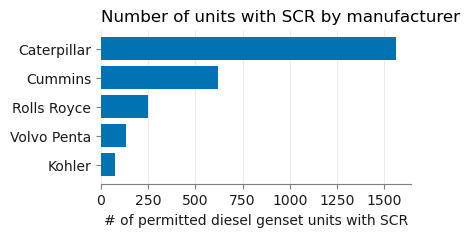

In [41]:
# With SCR
fig,ax=plt.subplots(figsize=(4,2))
# Exclude NG for this plot, and just show the top 6 manufacturers
df[df.SCR==True]['manufacturer'].value_counts().head(6).sort_values(ascending=True).plot(kind='barh',width=0.8)
ax.set_ylabel('')
ax.set_xlabel('# of permitted diesel genset units with SCR')#\nin VA through 2025
ax.set_title("Number of units with SCR by manufacturer")
ax.grid(visible=False, which='major', axis='y')
#ax.set_clip_on(False)
plt.show()

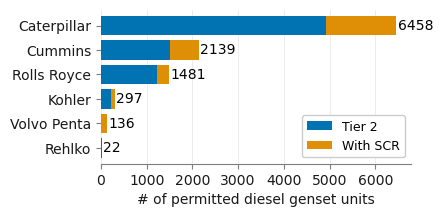

In [43]:
# Stacked bar plot by manufacturer
# Select only diesel generators, group by manufacturer, and add up how many of SCR=True and False for each
mfgs = df[df.fuel_type=='diesel'].groupby(['manufacturer'])['SCR'].value_counts().unstack(fill_value=0)
# Now sort by the most total units, and take only the top 6 manufacturers
mfgs = mfgs.loc[mfgs.sum(axis=1).sort_values(ascending=False)[:6].index,:]
mfgs = mfgs.replace(0, 1e-9) # swap zero values with a small value so that bar labels are properly calculated
ax = mfgs.iloc[::-1].plot(kind='barh', stacked=True, figsize=(4,2),width=0.8,legend=None)
ax.legend(labels=['Tier 2', 'With SCR'],framealpha=1,loc='lower right',fontsize=9)
ax.set_ylabel('')
ax.set_xlabel('# of permitted diesel genset units')
ax.grid(visible=False, which='major', axis='y')
barlabels = ax.bar_label(ax.containers[1],fmt='%.0f',padding=1)
plt.show()

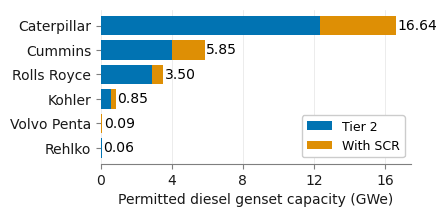

In [44]:
# Stacked bar plot by manufacturer
# Select only diesel generators, group by manufacturer, and add up how many of SCR=True and False for each
mfgs = df[df.fuel_type=='diesel'].groupby(['manufacturer','SCR'])['capacity_GWe'].sum().unstack(fill_value=0)
# Now sort by the most total units, and take only the top 6 manufacturers
mfgs = mfgs.loc[mfgs.sum(axis=1).sort_values(ascending=False)[:6].index,:]
mfgs = mfgs.replace(0, 1e-9) # swap zero values with a small value so that bar labels are properly calculated
ax = mfgs.iloc[::-1].plot(kind='barh', stacked=True, figsize=(4,2),width=0.8,legend=None)
ax.legend(labels=['Tier 2', 'With SCR'],framealpha=1,fontsize=9)
ax.set_ylabel('')
ax.set_xlabel('Permitted diesel genset capacity (GWe)')
ax.set_xticks([0,4,8,12,16])
barlabels = ax.bar_label(ax.containers[1],fmt='%.2f',padding=1)
ax.grid(visible=False, which='major', axis='y')
plt.show()

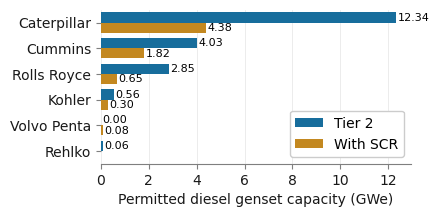

In [45]:
fig,ax=plt.subplots(figsize=(4,2))
# Get the top 6 manufacturers
mfgs = df[df.fuel_type=='diesel']['manufacturer'].value_counts().head(6).index
sns.barplot(
    data=df[df.manufacturer.isin(mfgs)],x='capacity_GWe',y='manufacturer',hue='SCR',estimator='sum',
    order = df[df.fuel_type=='diesel']['manufacturer'].value_counts().head(6).index,
    errorbar=None,ax=ax,legend=False)
ax.set_ylabel('')
ax.set_xlabel('Permitted diesel genset capacity (GWe)')
ax.legend(labels=['Tier 2', 'With SCR'],framealpha=1)
barlabels = ax.bar_label(ax.containers[0],fmt='%.2f',padding=1,fontsize=8)
barlabels = ax.bar_label(ax.containers[1],fmt='%.2f',padding=1,fontsize=8)
plt.show()

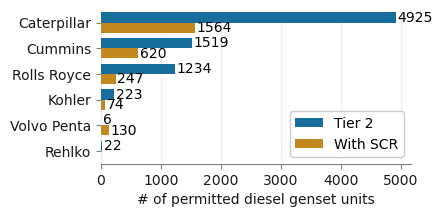

In [46]:
fig,ax=plt.subplots(figsize=(4,2))
# Get the top 6 manufacturers
mfgs = df[df.fuel_type=='diesel']['manufacturer'].value_counts().head(6).index
sns.countplot(data=df[df.manufacturer.isin(mfgs)],y='manufacturer',hue='SCR',
              order = df[df.fuel_type=='diesel']['manufacturer'].value_counts().head(6).index,
              ax=ax,legend=False)
ax.set_ylabel('')
ax.set_xlabel('# of permitted diesel genset units')
ax.legend(labels=['Tier 2', 'With SCR'],framealpha=1)
barlabels = ax.bar_label(ax.containers[0],fmt='%.0f',padding=1)
barlabels = ax.bar_label(ax.containers[1],fmt='%.0f',padding=1)
plt.show()

In [47]:
# Simplify model names to merge related models
df.loc[:,'model_simple'] = df.model.copy()
replacements = {
    'C3000 D6e':'C3000D6e',
    ' QSK95-G12':'',
    ' QSK95':'',
    'C3000D6E':'C3000D6e',
    
}
for old,new in replacements.items():
    df.loc[:,'model_simple'] = df.model_simple.str.replace(old,new)

families = {
    '16V4000':'MTU 16V4000',
    '20V4000':'MTU 20V4000'
}
for old,new in families.items():
    df.loc[df.model_simple.str.contains(old,na=False),'model_simple'] = new
df.model_simple.value_counts().head(20)

model_simple
3516C-HD           1796
3516E              1554
3516C              1190
C175-16            1091
MTU 16V4000        1075
C3000D6e           1014
MTU 20V4000         370
C175 DITA           237
2000DQKAB           145
QSK60-G26           140
TWD1673GE           130
C3250D6E            120
3512C               117
3516B               101
QSK95-G11            90
KD103V20             74
KD3000               69
C18                  69
KD2250               64
QSK60-G19 DQKAN      63
Name: count, dtype: int64

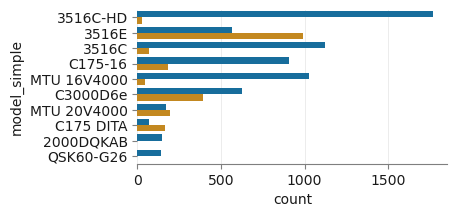

In [48]:
fig,ax=plt.subplots(figsize=(4,2))
# Get the top 6 manufacturers
models = df[df.fuel_type=='diesel']['model_simple'].value_counts().head(10)
sns.countplot(data=df[df.model_simple.isin(models.index)],y='model_simple',hue='SCR',
              order = models.index,
              ax=ax,legend=False)
plt.show()

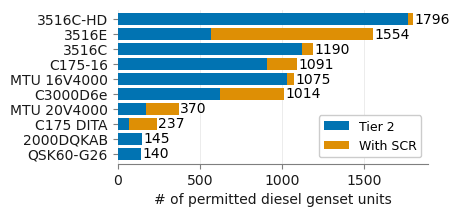

In [49]:
# Stacked bar plot by model
# Select only diesel generators, group by model, and add up how many of SCR=True and False for each
models = df[df.fuel_type=='diesel'].groupby(['model_simple'])['SCR'].value_counts().unstack(fill_value=0)
# Now sort by the most total units, and take only the top 6 manufacturers
models = models.loc[models.sum(axis=1).sort_values(ascending=False)[:10].index,:]
models = models.replace(0, 1e-9) # swap zero values with a small value so that bar labels are properly calculated

ax = models.iloc[::-1].plot(kind='barh', stacked=True, figsize=(4,2),width=0.8,legend=None)
ax.legend(labels=['Tier 2', 'With SCR'],framealpha=1,loc='lower right',fontsize=9)
ax.set_ylabel('')
ax.set_xlabel('# of permitted diesel genset units')
ax.grid(visible=False, which='major', axis='y')
barlabels = ax.bar_label(ax.containers[1],fmt='%.0f',padding=1)
plt.show()

# Sites and operators

In [50]:
df[df.original_permit_date<'2024-06-01'].groupby(['site_location'])['capacity_GWe'].sum().sort_values(ascending=False).head(20)

site_location
44274, 44372, 44751, and 44540 Round Table Plaza, Ashburn, Virginia 20147; 22125 Broderick Drive and 44820 Prentice Drive, Sterling, Virginia 20166    0.71585
LC1A - 21955 Loudoun County Parkway LC1B - 21955 Loudoun County Parkway LC2 - 44621 Waxpool Road LC3 - 44631 Waxpool Road Ashburn, VA 20147            0.57000
9905 Godwin Dr and 10050 and 10051 Brickyard Way Manassas, Virginia 20110                                                                              0.42775
960 Prison Road Boydton, VA  23917                                                                                                                     0.42350
608 Ridge Road Boydton, VA  23917                                                                                                                      0.41295
101 Herbert Drive near Boydton, Virginia                                                                                                               0.40805
20491 Goose Landing Lane Leesbur

In [51]:
# Simplify model names to merge related models
df.loc[:,'company_simple'] = df.company.copy()

corps = {
    'Microsoft':'Microsoft',
    'Amazon':'Amazon',
    'Digital Realty':'Digital Realty',
    'CyrusOne':'CyrusOne',
    'Darab':'Darab Ventures',
    'Quality Investment Properties':'Quality Investment\n Properties',
}
for old,new in corps.items():
    df.loc[df.company.str.contains(old,na=False),'company_simple'] = new

In [52]:
corps

{'Microsoft': 'Microsoft',
 'Amazon': 'Amazon',
 'Digital Realty': 'Digital Realty',
 'CyrusOne': 'CyrusOne',
 'Darab': 'Darab Ventures',
 'Quality Investment Properties': 'Quality Investment\n Properties'}

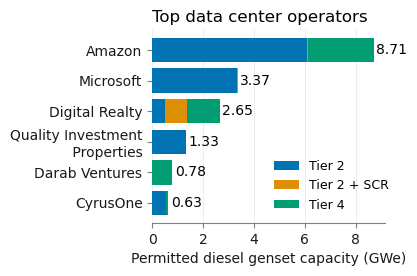

In [53]:
# Stacked bar plot by company/operator
# Select only diesel generators, group by manufacturer, and add up capacity for SCR=True and False for each
corps = df[df.fuel_type=='diesel'].groupby(['company_simple','tier_simple'])['capacity_GWe'].sum().unstack(fill_value=0)
# Now sort by the most total units, and take only the top 6 companies
corps = corps.loc[corps.sum(axis=1).sort_values(ascending=False)[:6].index,:]
ax = corps.iloc[::-1].plot(kind='barh', stacked=True, figsize=(3,2.5),width=0.8,legend=None)
ax.legend(framealpha=0,fontsize=9,bbox_to_anchor=(0.475,0),loc='lower left')
ax.set_ylabel('')
ax.set_xlabel('Permitted diesel genset capacity (GWe)')
ax.set_title('Top data center operators')
for vi,val in enumerate(corps.sum(axis=1).values[::-1]):
    ax.text(val+0.1,vi,f"{val:.2f}",va="center")
ax.grid(visible=False, which='major', axis='y')
plt.show()

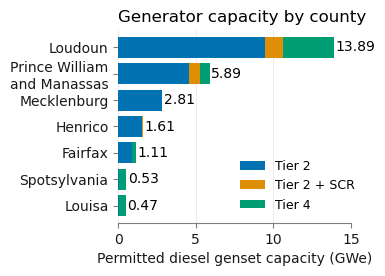

In [54]:
df.loc[:,'county_simple'] = df.county.copy()
swap = {
    'Prince William':'Prince William\nand Manassas',
    'City of Manassas':'Prince William\nand Manassas'
}
for old,new in swap.items():
    df.loc[df.county.str.contains(old,na=False),'county_simple'] = new
# Stacked bar plot by county
# Select only diesel generators, group by manufacturer, and add up capacity for SCR=True and False for each
counties = df[df.fuel_type=='diesel'].groupby(['county_simple','tier_simple'])['capacity_GWe'].sum().unstack(fill_value=0)
# Now sort by the most total units, and take only the top 6 companies
counties = counties.loc[counties.sum(axis=1).sort_values(ascending=False)[:7].index,:]
#mfgs

ax = counties.iloc[::-1].plot(kind='barh', stacked=True, figsize=(3,2.5),width=0.8,legend=None)
ax.legend(framealpha=0,fontsize=9,bbox_to_anchor=(0.475,0),loc='lower left')
#ax.legend(labels=['Tier 2', 'With SCR'],framealpha=1,fontsize=9)
ax.set_ylabel('')
ax.set_xlabel('Permitted diesel genset capacity (GWe)')
ax.set_title('Generator capacity by county')
ax.set_xticks([0,5,10,15])
#barlabels = ax.bar_label(ax.containers[2],fmt='%.2f',padding=1)
for vi,val in enumerate(counties.sum(axis=1).values[::-1]):
    ax.text(val+0.1,vi,f"{val:.2f}",va="center")
ax.grid(visible=False, which='major', axis='y')
plt.show()